# Customer Churn Prediction

## Objective

The goal of this notebook is to build a machine learning model that predicts customer churn behavior.

Business value:
- Identify customers at risk of not returning
- Support retention strategies
- Improve long-term customer value

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/poemshijin/customeranalyticssalesintelligence-olist-dataset/processed_master_dataset.csv")

# Convert Datetime

In [3]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Define Churn

## Churn Definition

A customer is considered "churned" if they made only one purchase during the observation period.

Reasoning:
- The dataset indicates low repeat purchase behavior
- Customers with only one order are treated as inactive or non-retained

Create Target Variable

In [4]:
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

df['churn'] = df['customer_unique_id'].map(
    lambda x: 1 if customer_orders[x] == 1 else 0
)

# Feature Selection

Select Features

In [5]:
features = [
    'order_value',
    'delivery_time',
    'total_items',
    'payment_types',
    'installments',
    'recency_days'
]

target = 'churn'

Create Modeling Dataset

In [6]:
model_df = df[features + [target]].copy()

# Handle Missing Values

In [7]:
model_df = model_df.dropna()

# Split Features and Labels

In [8]:
X = model_df[features]
y = model_df[target]

# Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model

In [17]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Evaluate Logistic Regression

In [18]:
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy: 0.5799212190318234

Classification Report:
              precision    recall  f1-score   support

           0       0.07      0.51      0.13      1184
           1       0.95      0.58      0.72     18110

    accuracy                           0.58     19294
   macro avg       0.51      0.55      0.43     19294
weighted avg       0.89      0.58      0.69     19294



Confusion Matrix

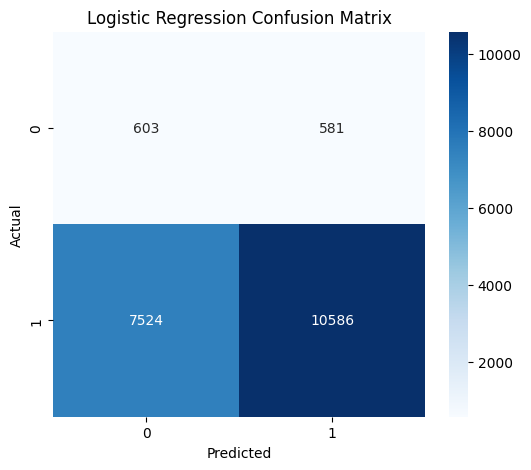

In [19]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Random Forest Model

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Evaluate Random Forest

In [25]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.9383227946511868

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.03      0.05      1184
           1       0.94      1.00      0.97     18110

    accuracy                           0.94     19294
   macro avg       0.70      0.51      0.51     19294
weighted avg       0.91      0.94      0.91     19294



# Feature Importance Ranking

In [28]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

importance_df

,feature,importance
0,order_value,0.394798
5,recency_days,0.348710
1,delivery_time,0.183895
4,installments,0.051970
2,total_items,0.015499
3,payment_types,0.005128


Visualization

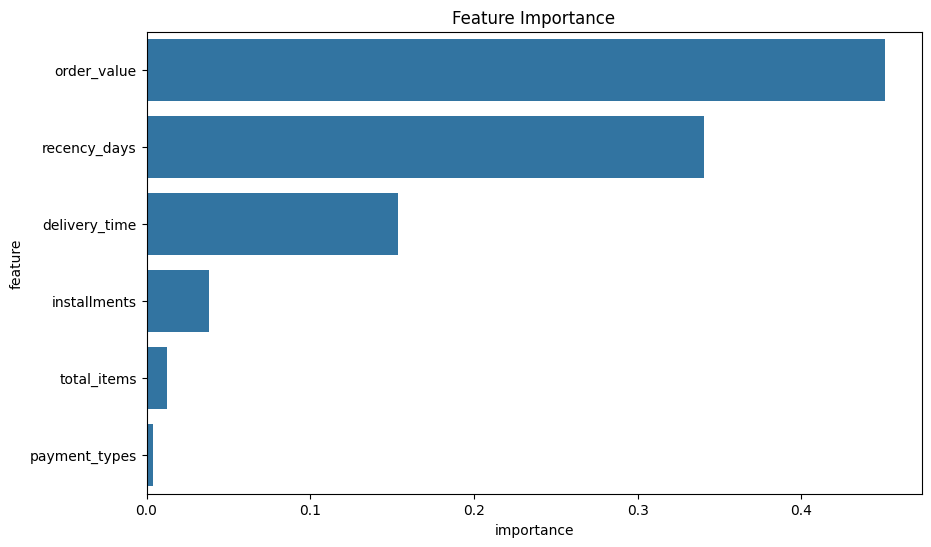

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='importance',
    y='feature'
)

plt.title("Feature Importance")

plt.show()

## Class Imbalance Observation

The dataset shows strong class imbalance:
- Most customers only purchased once
- Repeat customers represent a minority class

As a result:
- Accuracy alone is not a reliable metric
- Recall and F1-score are more appropriate for evaluation

To address imbalance:
- Class weighting was applied during model training

# Modeling Insights

# Modeling Insights

## Key Findings

- Customer recency is one of the strongest indicators of churn
- Delivery performance also impacts customer retention behavior
- Customers with higher engagement tend to have lower churn probability

## Business Implications

Potential retention strategies:
- Re-engage inactive customers earlier
- Improve delivery consistency
- Provide loyalty incentives for repeat purchases

# Model Comparison

# Model Evaluation Discussion

Two models were evaluated:

## Logistic Regression (Balanced)

Advantages:
- Better detection of minority class (non-churn customers)
- More balanced recall across classes

Limitations:
- Lower overall accuracy
- Higher false positive rate

## Random Forest

Advantages:
- High overall accuracy

Limitations:
- Severe bias toward majority class
- Poor minority class detection

Key takeaway:
- Accuracy alone is misleading due to class imbalance
- Recall and F1-score provide more meaningful evaluation

# Final Conclusion

# Conclusion

This project successfully:
- Processed relational e-commerce data
- Generated business insights through EDA
- Built churn prediction models
- Identified key drivers of customer retention

Future improvements:
- Add customer segmentation
- Use time-series forecasting
- Deploy models into interactive dashboards or APIs